# Train RNN

This notebook trains a stock-only RNN baseline.

Split:
- train: 2010–2018
- validation: 2019–2021
- test: 2022–2026

Results are saved under `outputs/figures` and `outputs/metrics`.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.dataset import StockSequenceDataset, print_dataset_summary
from src.models import build_model, count_parameters

def rel_path(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.as_posix()

print("Setup complete.")
print("CUDA available:", torch.cuda.is_available())

Setup complete.
CUDA available: True


## Config

In [2]:
CSV_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

TRAIN_END = "2018-12-31"
VAL_END = "2021-12-31"

MODEL_TYPE = "RNN"
EXPERIMENT_NAME = "rnn"

LOOKBACK = 30
NUM_CLASSES = 3
LABEL_NAMES = ["down", "flat", "up"]

HIDDEN_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.2
BIDIRECTIONAL = False

BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
EPOCHS = 5
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = 1.0

MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CSV exists:", CSV_PATH.exists())
print("Model:", MODEL_TYPE)
print("Device:", DEVICE)

CSV exists: True
Model: RNN
Device: cuda


## Seed

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

## Load data

In [4]:
train_dataset = StockSequenceDataset(str(CSV_PATH), split="train", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)
val_dataset = StockSequenceDataset(str(CSV_PATH), split="val", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)
test_dataset = StockSequenceDataset(str(CSV_PATH), split="test", lookback=LOOKBACK, train_end=TRAIN_END, val_end=VAL_END)

print_dataset_summary(train_dataset, "Train Dataset")
print_dataset_summary(val_dataset, "Validation Dataset")
print_dataset_summary(test_dataset, "Test Dataset")

INPUT_DIM = train_dataset.X.shape[-1]
print("INPUT_DIM:", INPUT_DIM)

[train] Number of feature columns: 13
[train] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
[val] Number of feature columns: 13
[val] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
[test] Number of feature columns: 13
[test] Feature columns: ['daily_return', 'log_return', 'open_close_return', 'high_low_range', 'volume_change', 'ma_5_ratio', 'ma_10_ratio', 'ma_20_ratio', 'volatility_5', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']
Train Dataset
Number of samples: 1005533
X shape: (1005533, 30, 13)
y shape: (1005533,)
Target distribution:
  0: 312017 (31.03%)
  1: 283953 (28.24%)
  2: 409563 (40.73%)
Date range:
201

## DataLoaders

In [5]:
def maybe_subset(dataset, max_samples, seed=42):
    if max_samples is None or len(dataset) <= max_samples:
        return dataset
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(dataset), size=max_samples, replace=False)
    return Subset(dataset, np.sort(idx).tolist())

train_data = maybe_subset(train_dataset, MAX_TRAIN_SAMPLES, SEED)
val_data = maybe_subset(val_dataset, MAX_VAL_SAMPLES, SEED)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("Train samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_dataset))

Train samples: 1005533
Validation samples: 368455
Test samples: 541680


## Build model

In [6]:
model = build_model(
    model_type=MODEL_TYPE,
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(model)
print("Trainable parameters:", count_parameters(model))

RecurrentClassifier(
  (rnn): RNN(13, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=64, out_features=3, bias=True)
  )
)
Trainable parameters: 5251


## Helper functions

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip_norm=None):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for X, y in tqdm(loader, desc="Training", leave=False):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        optimizer.step()

        total_loss += loss.item() * X.size(0)
        all_preds.append(torch.argmax(logits, dim=1).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
    )


@torch.no_grad()
def evaluate_with_probs(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_targets, all_preds, all_probs = [], [], []

    for X, y in tqdm(loader, desc="Evaluating", leave=False):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)
        loss = criterion(logits, y)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * X.size(0)
        all_targets.append(y.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
        y_true,
        y_pred,
        probs,
    )


def plot_confusion_matrix(cm, title, save_path, labels):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(ticks=np.arange(len(labels)), labels=labels)
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## Train

In [8]:
history = []
best_state = None
best_val_macro_f1 = -1.0
best_epoch = None

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP_NORM
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1, y_val_true, y_val_pred, val_probs = evaluate_with_probs(
        model, val_loader, criterion, DEVICE
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_macro_f1": train_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
    })

    print(f"train_loss={train_loss:.4f} | train_macro_f1={train_macro_f1:.4f}")
    print(f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

print(f"\nTraining time: {time.time() - start_time:.2f} seconds")
history_df = pd.DataFrame(history)
history_df


Epoch 1/5


Training:   0%|          | 0/982 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

train_loss=1.0723 | train_macro_f1=0.2753
val_loss=1.0541 | val_macro_f1=0.2951

Epoch 2/5


Training:   0%|          | 0/982 [00:00<?, ?it/s]

...

train_loss=1.0683 | train_macro_f1=0.2976
val_loss=1.0499 | val_macro_f1=0.2947

Epoch 5/5


Training:   0%|          | 0/982 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

train_loss=1.0679 | train_macro_f1=0.3010
val_loss=1.0491 | val_macro_f1=0.2709

Training time: 490.50 seconds


,epoch,train_loss,train_acc,train_macro_f1,train_weighted_f1,val_loss,val_acc,val_macro_f1,val_weighted_f1
0,1,1.072346,0.413373,0.275334,0.304677,1.054136,0.445403,0.295099,0.342000
1,2,1.069261,0.416343,0.289878,0.316753,1.050535,0.446068,0.278979,0.331683
2,3,1.068654,0.417263,0.293651,0.319875,1.050719,0.447506,0.290850,0.336538
3,4,1.068296,0.417676,0.297649,0.323384,1.049874,0.448608,0.294654,0.340575
4,5,1.067893,0.418098,0.301031,0.326301,1.049114,0.448706,0.270909,0.325160


## Training curves

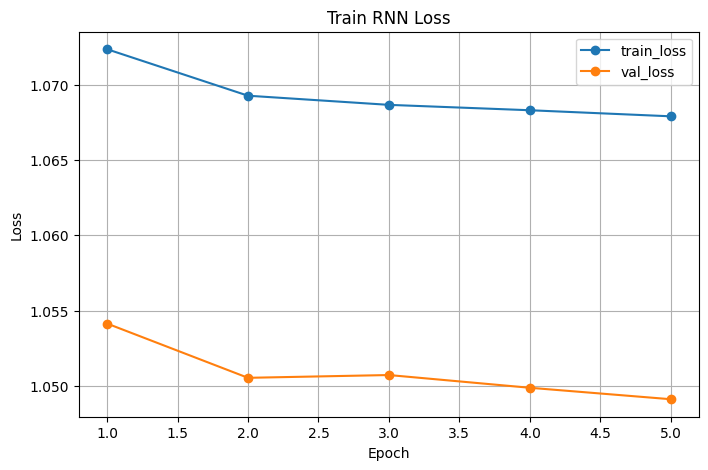

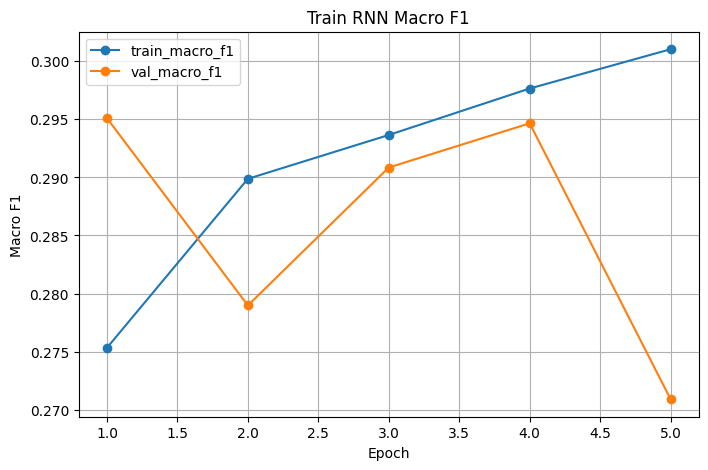

In [9]:
figures_dir = PROJECT_ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train RNN Loss")
plt.legend()
plt.grid(True)
plt.savefig(figures_dir / "rnn_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="train_macro_f1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Train RNN Macro F1")
plt.legend()
plt.grid(True)
plt.savefig(figures_dir / "rnn_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## Validation and test reports

In [10]:
model.load_state_dict(best_state)
print("Best epoch:", best_epoch)
print("Best validation macro F1:", best_val_macro_f1)

val_loss, val_acc, val_macro_f1, val_weighted_f1, y_val_true, y_val_pred, val_probs = evaluate_with_probs(
    model, val_loader, criterion, DEVICE
)

test_loss, test_acc, test_macro_f1, test_weighted_f1, y_test_true, y_test_pred, test_probs = evaluate_with_probs(
    model, test_loader, criterion, DEVICE
)

print("\nValidation")
print("Loss:", val_loss)
print("Accuracy:", val_acc)
print("Macro F1:", val_macro_f1)
print("Weighted F1:", val_weighted_f1)
print(classification_report(y_val_true, y_val_pred, target_names=LABEL_NAMES, digits=4))

print("\nTest")
print("Loss:", test_loss)
print("Accuracy:", test_acc)
print("Macro F1:", test_macro_f1)
print("Weighted F1:", test_weighted_f1)
print(classification_report(y_test_true, y_test_pred, target_names=LABEL_NAMES, digits=4))

val_cm = confusion_matrix(y_val_true, y_val_pred)
test_cm = confusion_matrix(y_test_true, y_test_pred)

Best epoch: 1
Best validation macro F1: 0.2950987831419325


Evaluating:   0%|          | 0/360 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/529 [00:00<?, ?it/s]


Validation
Loss: 1.0541362595641315
Accuracy: 0.44540310214273116
Macro F1: 0.2950987831419325
Weighted F1: 0.34200048891446194
              precision    recall  f1-score   support

        down     0.4068    0.0428    0.0774    116598
        flat     0.3737    0.1421    0.2059     87428
          up     0.4543    0.8922    0.6020    164429

    accuracy                         0.4454    368455
   macro avg     0.4116    0.3590    0.2951    368455
weighted avg     0.4201    0.4454    0.3420    368455


Test
Loss: 1.0656811367935488
Accuracy: 0.4143276473194506
Macro F1: 0.23673436005952028
Weighted F1: 0.2756804322876919
              precision    recall  f1-score   support

        down     0.3999    0.0200    0.0381    194942
        flat     0.3351    0.0533    0.0919    121382
          up     0.4176    0.9499    0.5801    225356

    accuracy                         0.4143    541680
   macro avg     0.3842    0.3411    0.2367    541680
weighted avg     0.3927    0.4143    0.275

## Save results

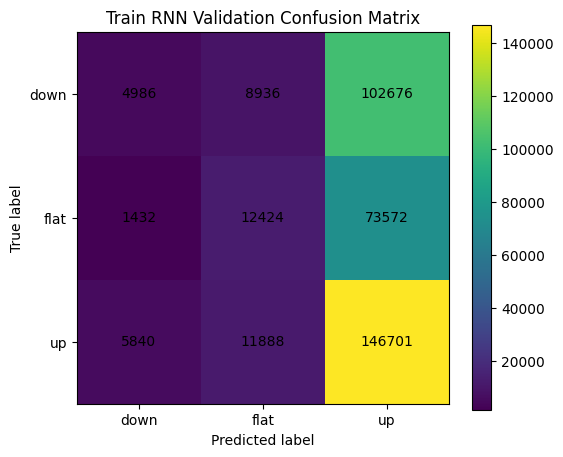

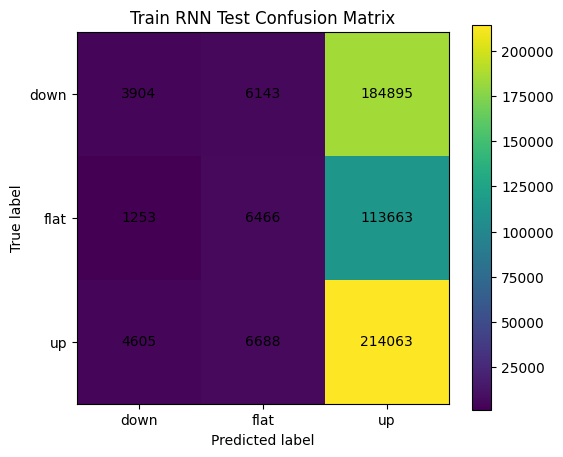

Saved: outputs/metrics/rnn_summary.csv


,model,split,loss,accuracy,macro_f1,weighted_f1,down_f1,flat_f1,up_f1,best_epoch,input_dim,hidden_dim,num_layers,dropout,learning_rate
0,rnn,validation,1.054136,0.445403,0.295099,0.34200,0.077389,0.205907,0.602001,1,13,64,1,0.2,0.001
1,rnn,test,1.065681,0.414328,0.236734,0.27568,0.038143,0.091926,0.580135,1,13,64,1,0.2,0.001


In [11]:
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

plot_confusion_matrix(val_cm, "Train RNN Validation Confusion Matrix", figures_dir / "rnn_val_confusion_matrix.png", LABEL_NAMES)
plot_confusion_matrix(test_cm, "Train RNN Test Confusion Matrix", figures_dir / "rnn_test_confusion_matrix.png", LABEL_NAMES)

history_df.to_csv(metrics_dir / "rnn_history.csv", index=False)

val_report = classification_report(y_val_true, y_val_pred, target_names=LABEL_NAMES, output_dict=True, digits=4)
test_report = classification_report(y_test_true, y_test_pred, target_names=LABEL_NAMES, output_dict=True, digits=4)

summary_df = pd.DataFrame([
    {
        "model": EXPERIMENT_NAME,
        "split": "validation",
        "loss": val_loss,
        "accuracy": val_acc,
        "macro_f1": val_macro_f1,
        "weighted_f1": val_weighted_f1,
        "down_f1": val_report["down"]["f1-score"],
        "flat_f1": val_report["flat"]["f1-score"],
        "up_f1": val_report["up"]["f1-score"],
        "best_epoch": best_epoch,
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
    },
    {
        "model": EXPERIMENT_NAME,
        "split": "test",
        "loss": test_loss,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "weighted_f1": test_weighted_f1,
        "down_f1": test_report["down"]["f1-score"],
        "flat_f1": test_report["flat"]["f1-score"],
        "up_f1": test_report["up"]["f1-score"],
        "best_epoch": best_epoch,
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "learning_rate": LEARNING_RATE,
    },
])

summary_path = metrics_dir / "rnn_summary.csv"
summary_df.to_csv(summary_path, index=False)

if EXPERIMENT_NAME == "gru_weighted":
    summary_df.to_csv(metrics_dir / "gru_weighted_validation_vs_test.csv", index=False)

pd.DataFrame(val_cm, index=["true_down", "true_flat", "true_up"], columns=["pred_down", "pred_flat", "pred_up"]).to_csv(metrics_dir / "rnn_val_confusion_matrix.csv")
pd.DataFrame(test_cm, index=["true_down", "true_flat", "true_up"], columns=["pred_down", "pred_flat", "pred_up"]).to_csv(metrics_dir / "rnn_test_confusion_matrix.csv")

print("Saved:", rel_path(summary_path))
summary_df